# Synthetic

**This notebook illustrates the benefits of tensor rescaling and internals smoothing on a synthetic example.**

We show that our preprocessing step leads to:
1. both outputs being equally considered and minimized, and
2. stable condition numbers for our factor updates (especially for $H$ and $R$).

We then show that adding a smoothing penalty to our internals keeps the performance of our algorithm stable as $df \to N$.

Note that running this notebook requires a sufficiently large amount of RAM (~10gb).

## Setup

In [1]:
import warnings; warnings.simplefilter('ignore')
from tqdm import tqdm
import plotting

colors = plotting.setup()

In [2]:
import jax, jax.numpy as jnp

from decoupling import Algorithm
from decoupling.scaler import JacobianScaler
from decoupling.utils import function_error, collect_information_from_random

key      = jax.random.key(0)
key_test = jax.random.key(100)
nseeds   = 10
nsigmas  = 100
N        = 100

In [3]:
def make_target(sigma):
    def target(x):
        a, b = x
        return jnp.asarray([
            sigma*(jnp.cos(4 * jnp.pi * a) + b**2),
            -jnp.sin(3 * jnp.pi * b) + a**3,
        ])
    return target

## Scaling: Per-Output Errors 

In [4]:
def compare_errors(sigmas, scale, **kwargs):
    errors = []
    for sigma in tqdm(sigmas):

        target = make_target(sigma)
        mean_errors = jnp.zeros(2)
        count = 0

        X, Y, J = collect_information_from_random(target, kwargs['N'], 2, key)
        X_test, _, _ = collect_information_from_random(target, kwargs['N'], 2, key_test)
        
        if scale:
            scaler = JacobianScaler(J)
            Js, Ys = scaler.scale(J, Y)
            
        for k in jax.random.split(key, nseeds):
            try:
                algo = Algorithm(kwargs['rank'], k, use_smoothing=False, show_progress=False)
                if scale: decoupling = scaler.unscale(algo.run(X, Ys, Js))
                else: decoupling = algo.run(X, Y, J)
                mean_errors += function_error(target, decoupling, X_test)
                count += 1
            except: pass
                
        mean_errors = mean_errors / count
        errors.append(mean_errors)
        
    return jnp.stack(errors)

In [5]:
sigmas1 = jnp.logspace(0.0, 2.5, nsigmas)
sigmas1[-5:]

Array([250.6051 , 265.60883, 281.51065, 298.3647 , 316.22775], dtype=float32)

In [6]:
errors_before = compare_errors(sigmas1, scale=False, N=N, rank=4)

100%|██████████████████████████████████████████████████████████████████| 100/100 [04:48<00:00,  2.88s/it]


In [7]:
errors_after = compare_errors(sigmas1, scale=True, N=N, rank=4)

100%|██████████████████████████████████████████████████████████████████| 100/100 [05:13<00:00,  3.14s/it]


## Scaling: Condition Numbers

In [8]:
def compare_rconds(sigmas, scale, **kwargs):
    rcondsW = []; rcondsV = []; rcondsH = []; rcondsR = []

    for sigma in tqdm(sigmas):

        target = make_target(sigma)
        
        rcV = rcW = rcH = rcR = 0.0
        count = 0

        (X, Y, J) = collect_information_from_random(target, kwargs['N'], 2, key)

        if scale:
            scaler = JacobianScaler(J)
            Js, Ys = scaler.scale(J, Y)

        for k in jax.random.split(key, nseeds):
            try:
                algorithm = Algorithm(kwargs['rank'], k, use_smoothing=False, show_progress=False)
                if scale: decoupling = algorithm.run(X, Ys, Js)
                else: decoupling = algorithm.run(X, Y, J)
                rcW += jnp.median(algorithm.info.rconds['W'])
                rcV += jnp.median(algorithm.info.rconds['V'])
                rcH += jnp.median(algorithm.info.rconds['H'])
                rcR += jnp.median(algorithm.info.rconds['R'])
                count += 1
            except: pass

        rcW = rcW / count; rcV = rcV / count; rcH = rcH / count; rcR = rcR / count
        
        rcondsH.append(float(rcH)); rcondsR.append(float(rcR))
        rcondsW.append(float(rcW)); rcondsV.append(float(rcV))

    return (rcondsW, rcondsV, rcondsH, rcondsR)

In [9]:
sigmas2 = jnp.logspace(0, 6, nsigmas)
sigmas2[-3:]

Array([7.564635e+05, 8.697491e+05, 1.000000e+06], dtype=float32)

In [10]:
rconds_before = compare_rconds(sigmas2, scale=False, rank=4, N=N)

100%|██████████████████████████████████████████████████████████████████| 100/100 [02:19<00:00,  1.40s/it]


In [11]:
rconds_after = compare_rconds(sigmas2, scale=True, rank=4, N=N)

100%|██████████████████████████████████████████████████████████████████| 100/100 [02:16<00:00,  1.37s/it]


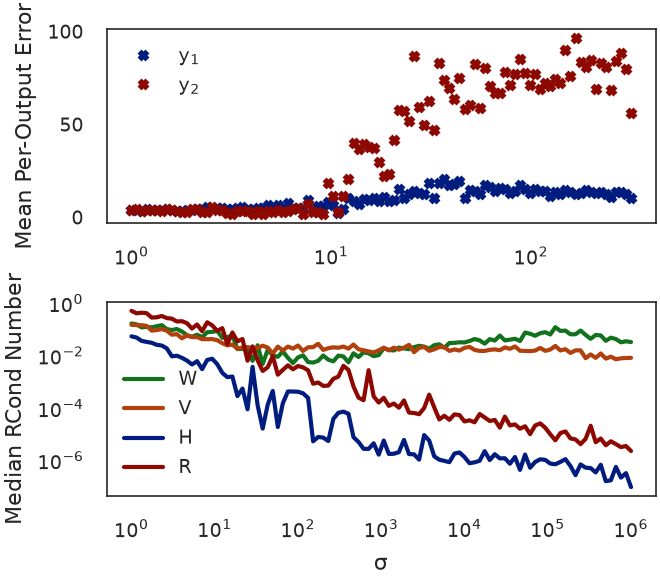

In [12]:
plotting.plot_before(sigmas1, sigmas2, errors_before, rconds_before, colors)

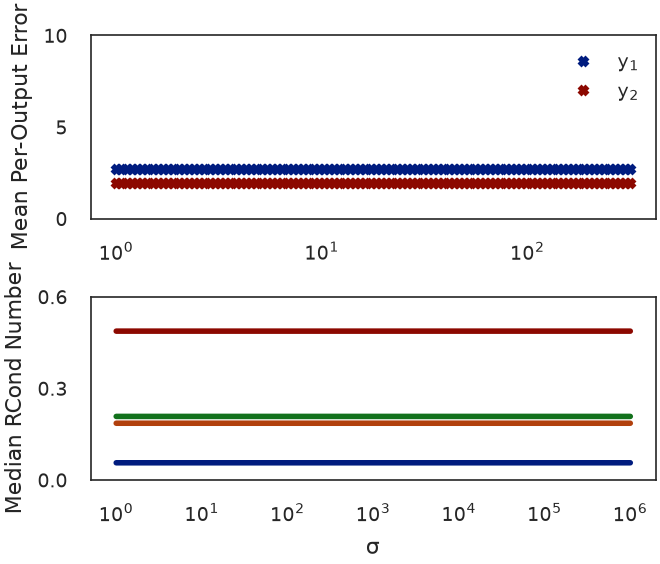

In [13]:
plotting.plot_after(sigmas1, sigmas2, errors_after, rconds_after, colors)

## 3. Smoothing

In [14]:
def compare_smoothing(dofs, nkeys, smoothing, blend=0.8, **kwargs):
    errors = []
    
    target = make_target(1.0)
    X, Y, J = collect_information_from_random(target, kwargs['N'], 2, key)
    X_test, _, _ = collect_information_from_random(target, kwargs['N'], 2, key_test)

    lambdas = jnp.linspace(-1, 8, num=4096)
    
    for dof in tqdm(dofs):
        
        mean_errors = jnp.zeros(2)
        count = 0
        
        for k in jax.random.split(key, nkeys):

            try:
            
                algorithm = Algorithm(
                    rank=kwargs['rank'],
                    key=k, 
                    use_smoothing=smoothing, 
                    show_progress=False,
                    splines_dof=int(dof),
                    smoothing_grid=lambdas,
                    knots_blend=blend,
                )
                
                decoupling = algorithm.run(X, Y, J)
                
                mean_errors += function_error(target, decoupling, X_test)
                count += 1

            except: pass
                
        mean_errors = mean_errors / count
        errors.append(mean_errors)
        
    return jnp.stack(errors)

In [15]:
dofs = jnp.arange(10, N+1, 1, dtype=jnp.int_)
dofs[-10:]

Array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100], dtype=int32)

In [16]:
errors_nosmoothing = compare_smoothing(dofs, nseeds, smoothing=False, N=N, rank=4)

100%|████████████████████████████████████████████████████████████████████| 91/91 [11:42<00:00,  7.72s/it]


In [17]:
errors_smoothing = compare_smoothing(dofs, nseeds, smoothing=True, N=N, rank=4, blend=1.0)

100%|████████████████████████████████████████████████████████████████████| 91/91 [14:57<00:00,  9.86s/it]


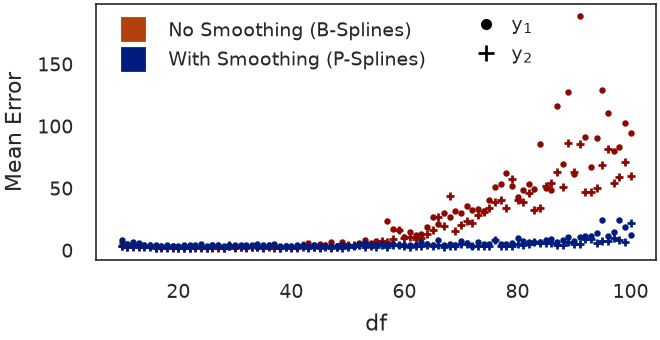

In [18]:
plotting.plot_smoothing1(dofs, errors_nosmoothing, errors_smoothing, colors)

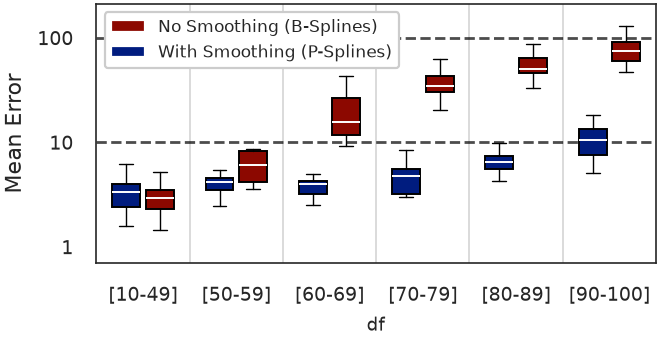

In [19]:
plotting.plot_smoothing2(dofs, errors_nosmoothing, errors_smoothing, colors)